# 01. 정밀 검사를 위한 이미지 정렬 및 ROI 추출

Severstal Steel Defect Detection 데이터 기반
- 원본 이미지: 256×1600 → 슬라이딩 윈도우(stride=128, 50% 오버랩) → 256×256 패치
- 정상 120,583장 + 결함 30,233장 (4종) — 총 150,816장
- v6.0: 경계 결함 포착을 위한 오버랩 패치 전략 적용
- 전처리 파이프라인: 정렬 → ROI → 정규화

In [1]:
import os, sys, cv2, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)

from utils.severstal_loader import CLASS_NAMES_KR, CLASS_ABBR
from utils.severstal_preprocessor import PatchDataLoader

PATCH_DIR = os.path.join(PROJECT_ROOT, 'data', 'severstal_patches')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures', 'severstal')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Patch Dir: {PATCH_DIR}")

Project Root: /Volumes/Corsair EX300U Media/00_work_out/01_complete/Phase9_v2
Patch Dir: /Volumes/Corsair EX300U Media/00_work_out/01_complete/Phase9_v2/data/severstal_patches


## Phase 1: 데이터 로드 및 탐색

Severstal 철강 표면 결함 데이터를 로드하고 기본 통계를 확인합니다.

In [2]:
loader = PatchDataLoader(PATCH_DIR)
loader.print_stats()

# 샘플 로드 (클래스당 50장)
print("\n[데이터 로드 중...]")
images_bin, labels_bin = loader.load_binary(max_per_class=50, resize=(256, 256), grayscale=True)
print(f"이진 분류 샘플: {len(images_bin)}장 (정상 {(labels_bin==0).sum()} / 비정상 {(labels_bin==1).sum()})")

images_d4, labels_d4 = loader.load_defect4(max_per_class=50, resize=(256, 256), grayscale=True)
print(f"4종 결함 샘플: {len(images_d4)}장")
for cid in [1,2,3,4]:
    print(f"  ClassId {cid} ({CLASS_ABBR[cid]}): {(labels_d4==cid).sum()}장")


Severstal 크롭 패치 — 통계
정상 패치: 120,583장
ClassId 1 (점상 결함 (PS)): 2,638장
ClassId 2 (선형 긁힘 (LS)): 457장
ClassId 3 (표면 변색 (SS)): 23,408장
ClassId 4 (압연 압흔 (RD)): 3,730장

총 비정상 패치: 30,233장
총 패치: 150,816장

[데이터 로드 중...]


이진 분류 샘플: 100장 (정상 50 / 비정상 50)
4종 결함 샘플: 200장
  ClassId 1 (PS): 50장
  ClassId 2 (LS): 50장
  ClassId 3 (SS): 50장
  ClassId 4 (RD): 50장


### 클래스별 대표 이미지 시각화

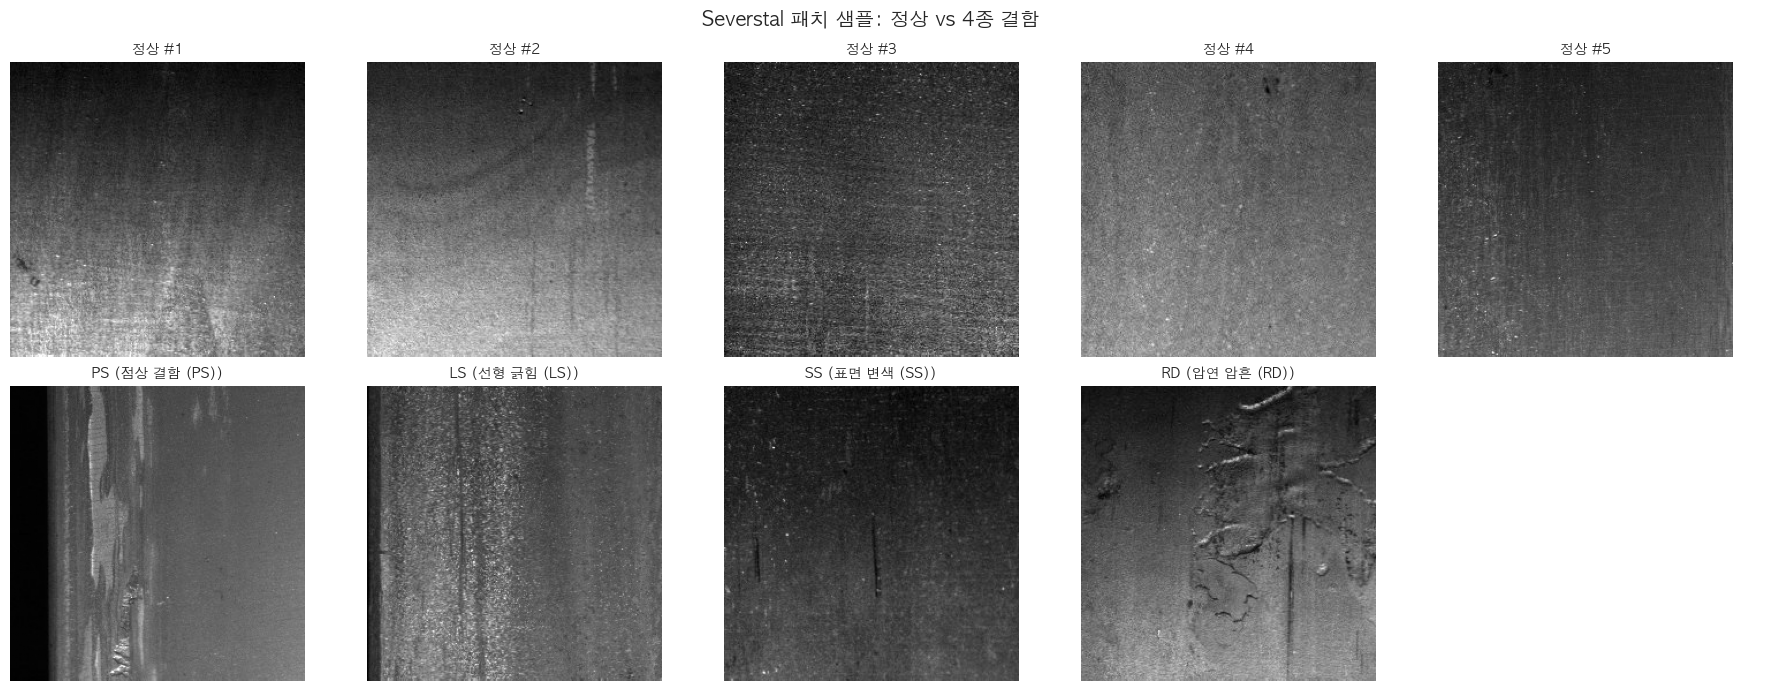

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# 정상 샘플
normal_imgs = images_bin[labels_bin == 0]
for i in range(5):
    axes[0, i].imshow(normal_imgs[i], cmap='gray')
    axes[0, i].set_title(f'정상 #{i+1}', fontsize=10)
    axes[0, i].axis('off')

# 결함 샘플 (4종 + 1 추가)
for i, cid in enumerate([1, 2, 3, 4]):
    mask = labels_d4 == cid
    if mask.sum() > 0:
        axes[1, i].imshow(images_d4[mask][0], cmap='gray')
        axes[1, i].set_title(f'{CLASS_ABBR[cid]} ({CLASS_NAMES_KR[cid]})', fontsize=10)
    axes[1, i].axis('off')
axes[1, 4].axis('off')

fig.suptitle('Severstal 패치 샘플: 정상 vs 4종 결함', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_class_samples.png'), dpi=150, bbox_inches='tight')
plt.show()

### 밝기 분포 분석

각 클래스별 픽셀 밝기 분포를 히스토그램으로 확인합니다. 클래스 간 밝기 차이가 크면 정규화가 필수적입니다.

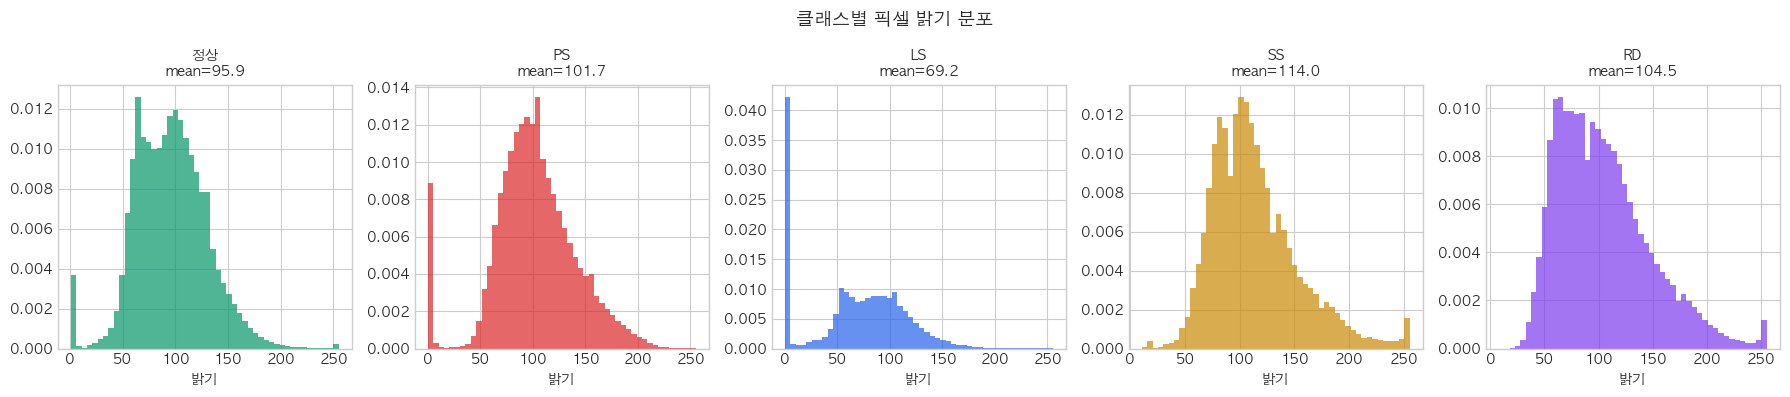

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# 정상
axes[0].hist(normal_imgs[:20].ravel(), bins=50, color='#059669', alpha=0.7, density=True)
axes[0].set_title(f'정상\nmean={normal_imgs[:20].mean():.1f}', fontsize=10)
axes[0].set_xlabel('밝기')

# 4종 결함
colors = ['#dc2626', '#2563eb', '#ca8a04', '#7c3aed']
for i, cid in enumerate([1, 2, 3, 4]):
    mask = labels_d4 == cid
    if mask.sum() > 0:
        data = images_d4[mask][:20]
        axes[i+1].hist(data.ravel(), bins=50, color=colors[i], alpha=0.7, density=True)
        axes[i+1].set_title(f'{CLASS_ABBR[cid]}\nmean={data.mean():.1f}', fontsize=10)
    axes[i+1].set_xlabel('밝기')

fig.suptitle('클래스별 픽셀 밝기 분포', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_brightness_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

### 통계 요약

클래스별 평균 밝기, 표준편차를 비교하여 정규화 필요성을 확인합니다.

In [5]:
import pandas as pd

stats = []
# 정상
stats.append({'클래스': '정상', 'Mean': normal_imgs[:50].mean(), 'Std': normal_imgs[:50].std(),
              'Min': normal_imgs[:50].min(), 'Max': normal_imgs[:50].max()})
for cid in [1, 2, 3, 4]:
    mask = labels_d4 == cid
    if mask.sum() > 0:
        data = images_d4[mask][:50]
        stats.append({'클래스': f'{CLASS_ABBR[cid]} ({CLASS_NAMES_KR[cid]})',
                      'Mean': data.mean(), 'Std': data.std(), 'Min': data.min(), 'Max': data.max()})

df_stats = pd.DataFrame(stats)
print("="*60)
print("클래스별 밝기 통계")
print("="*60)
print(df_stats.to_string(index=False, float_format='%.2f'))
print(f"\n→ 클래스 간 평균 밝기 범위: {df_stats['Mean'].max() - df_stats['Mean'].min():.1f}")
print("→ 정규화를 통해 클래스 간 밝기 차이를 줄여야 ML/DL 성능 향상 기대")

클래스별 밝기 통계
            클래스   Mean   Std  Min  Max
             정상  81.77 53.53    0  255
PS (점상 결함 (PS)) 101.63 37.71    0  255
LS (선형 긁힘 (LS))  72.39 44.93    0  255
SS (표면 변색 (SS)) 105.42 41.78    0  255
RD (압연 압흔 (RD))  97.99 45.22    2  255

→ 클래스 간 평균 밝기 범위: 33.0
→ 정규화를 통해 클래스 간 밝기 차이를 줄여야 ML/DL 성능 향상 기대


## Phase 2: 이미지 정렬 (Alignment)

Severstal 패치는 슬라이딩 윈도우로 크롭되어 별도의 기하학적 정렬이 불필요하지만,
실제 라인 카메라 환경에서는 미세 회전이 발생할 수 있어 자동 보정 기능을 시연합니다.

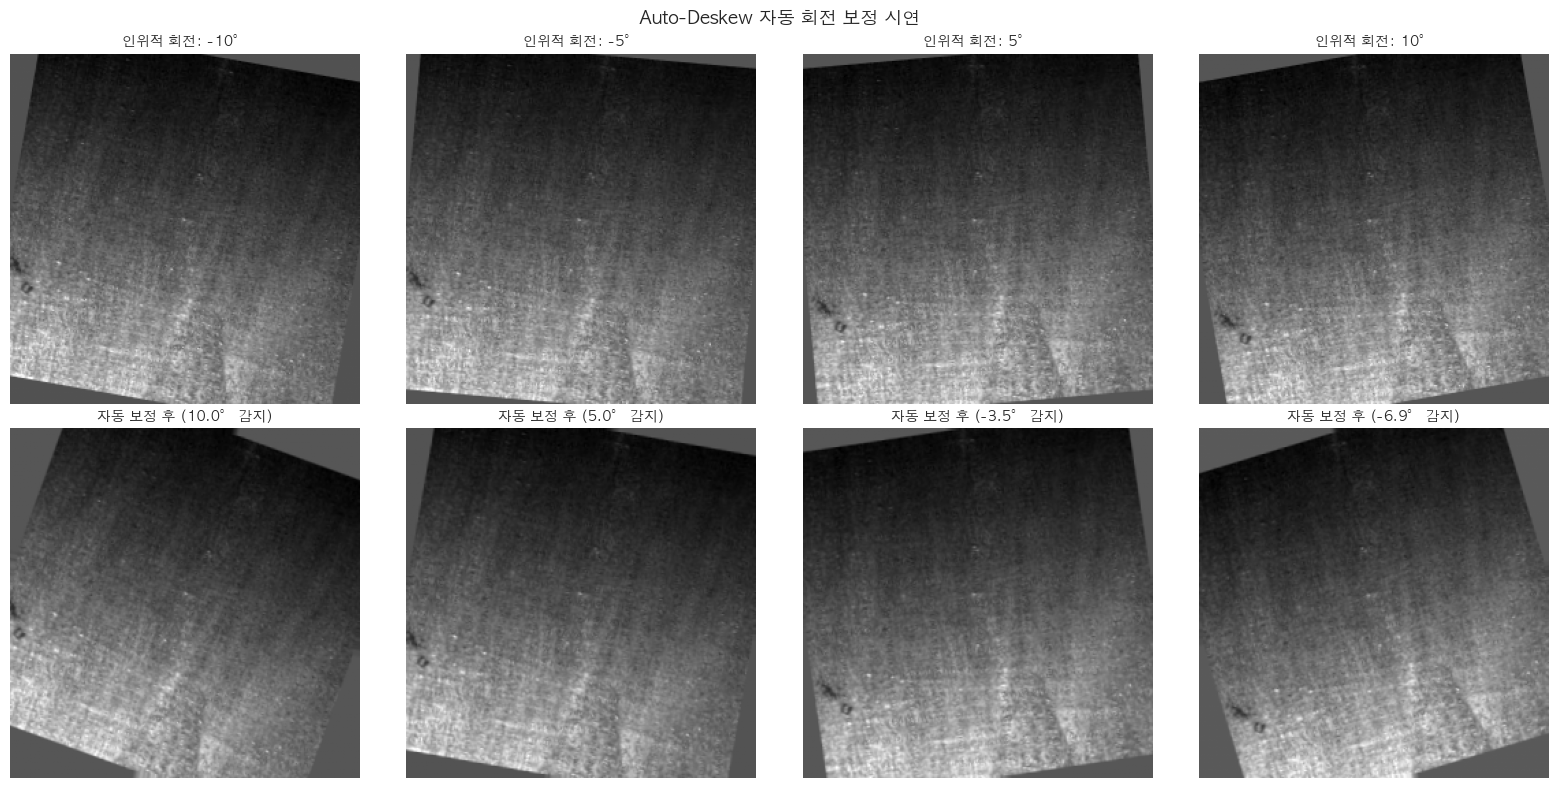

In [6]:
from preprocessing.alignment import auto_deskew

sample = normal_imgs[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
angles = [-10, -5, 5, 10]

for i, angle in enumerate(angles):
    h, w = sample.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    rotated = cv2.warpAffine(sample, M, (w, h), borderValue=int(sample.mean()))
    corrected, angle_detected = auto_deskew(rotated)
    
    axes[0, i].imshow(rotated, cmap='gray')
    axes[0, i].set_title(f'인위적 회전: {angle}°', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(corrected, cmap='gray')
    axes[1, i].set_title(f'자동 보정 후 ({angle_detected:.1f}° 감지)', fontsize=10)
    axes[1, i].axis('off')

fig.suptitle('Auto-Deskew 자동 회전 보정 시연', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_deskew_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

## Phase 3: ROI 추출

에지 밀도 기반으로 결함이 집중된 관심 영역(ROI)을 자동 추출합니다.

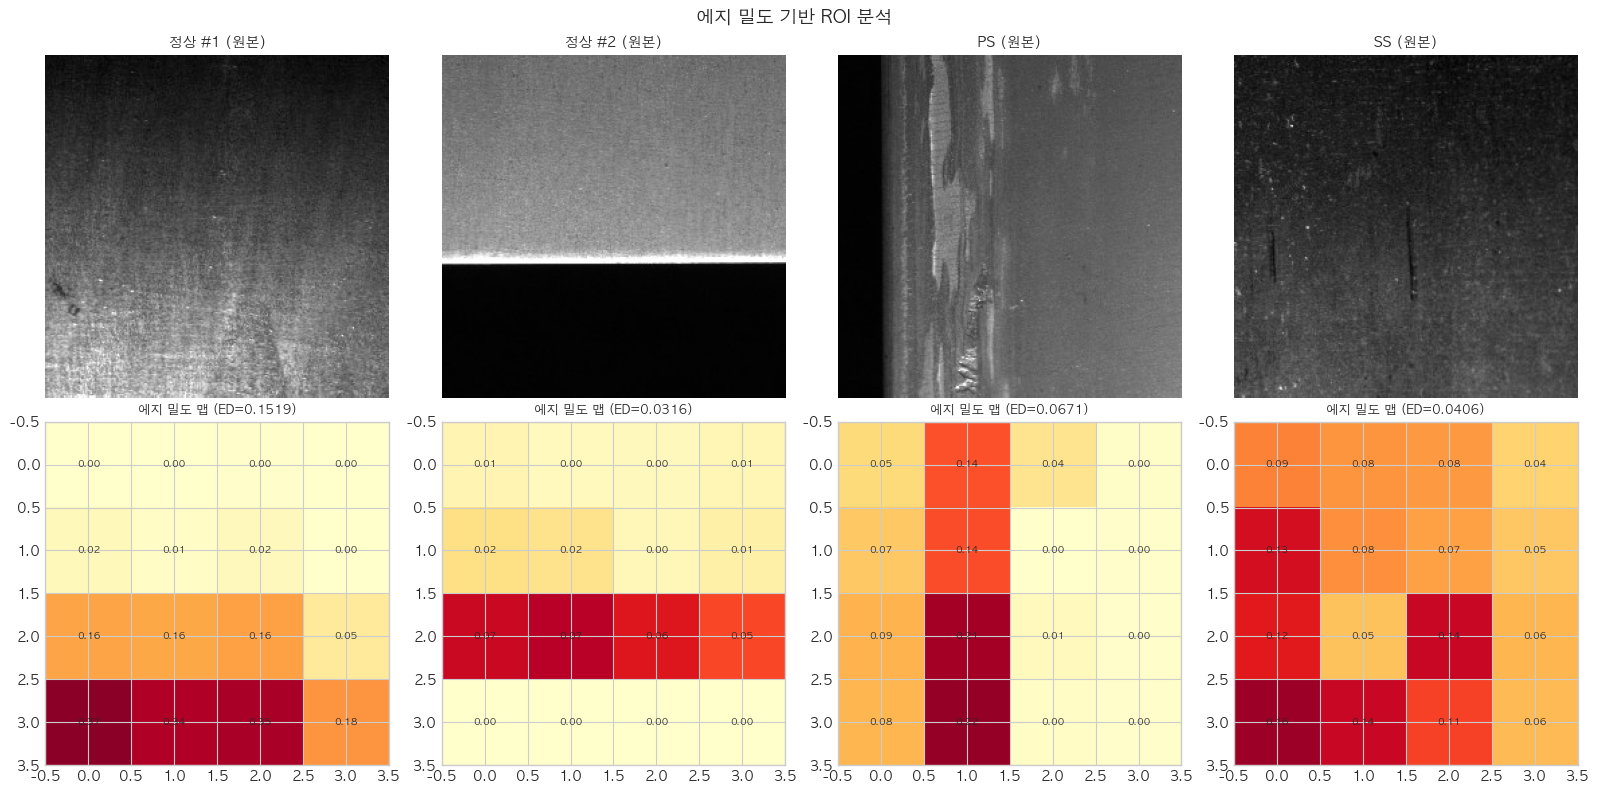

In [7]:
from preprocessing.edge_detection import auto_canny
from utils.filter_utils import compute_edge_density

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 정상 2장 + 결함 2장
demo_imgs = [normal_imgs[0], normal_imgs[5]]
demo_labels = ['정상 #1', '정상 #2']
for cid in [1, 3]:
    mask = labels_d4 == cid
    if mask.sum() > 0:
        demo_imgs.append(images_d4[mask][0])
        demo_labels.append(f'{CLASS_ABBR[cid]}')

for i, (img, label) in enumerate(zip(demo_imgs, demo_labels)):
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'{label} (원본)', fontsize=10)
    axes[0, i].axis('off')
    
    edge, _, _ = auto_canny(img)
    # 4×4 에지 밀도 맵
    h, w = edge.shape
    grid = np.zeros((4, 4))
    for r in range(4):
        for c in range(4):
            patch = edge[r*h//4:(r+1)*h//4, c*w//4:(c+1)*w//4]
            grid[r, c] = np.mean(patch > 0)
    
    axes[1, i].imshow(grid, cmap='YlOrRd', interpolation='nearest', vmin=0, vmax=grid.max()+0.01)
    axes[1, i].set_title(f'에지 밀도 맵 (ED={compute_edge_density(img):.4f})', fontsize=9)
    for r in range(4):
        for c in range(4):
            axes[1, i].text(c, r, f'{grid[r,c]:.2f}', ha='center', va='center', fontsize=7)

fig.suptitle('에지 밀도 기반 ROI 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_roi_edge_density.png'), dpi=150, bbox_inches='tight')
plt.show()

## Phase 4: 밝기·대비 정규화

CLAHE, 히스토그램 균등화 등 다양한 정규화 방법을 비교하여 최적 방법을 선택합니다.

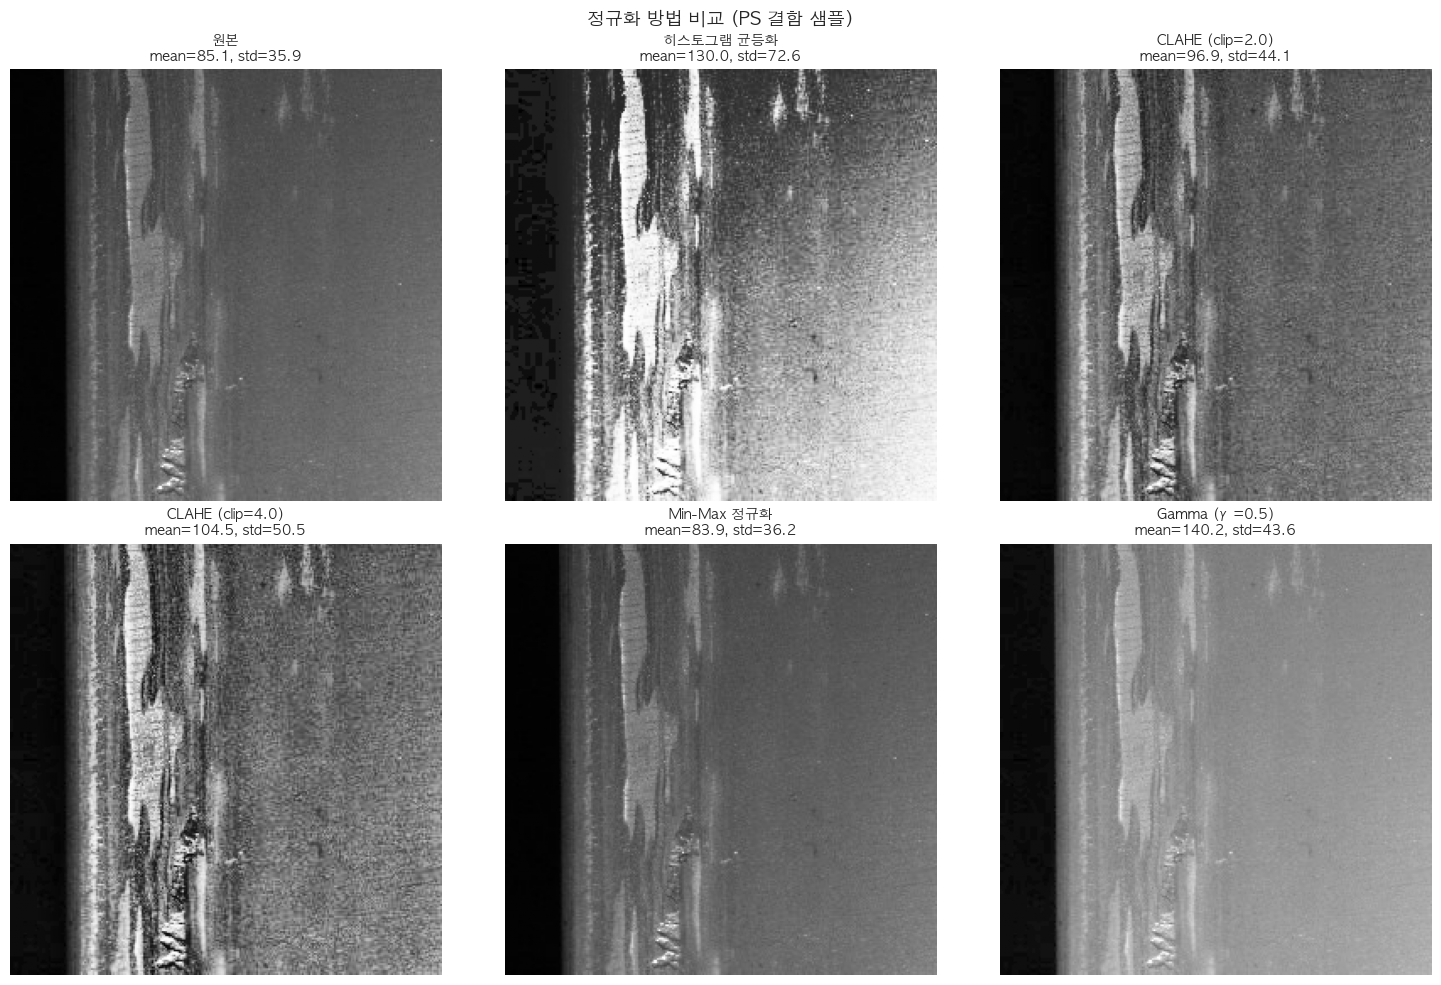

→ CLAHE (clip=2.0)이 결함을 가장 잘 보존하면서 대비를 개선
→ 히스토그램 균등화는 과도한 대비 증가로 노이즈 증폭 위험


In [8]:
from preprocessing.normalization import clahe_equalization

sample = images_d4[labels_d4 == 1][0] if (labels_d4==1).sum() > 0 else normal_imgs[0]

methods = {
    '원본': sample,
    '히스토그램 균등화': cv2.equalizeHist(sample),
    'CLAHE (clip=2.0)': clahe_equalization(sample, clip_limit=2.0),
    'CLAHE (clip=4.0)': clahe_equalization(sample, clip_limit=4.0),
    'Min-Max 정규화': cv2.normalize(sample, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8),
    'Gamma (γ=0.5)': np.clip(255 * (sample / 255.0) ** 0.5, 0, 255).astype(np.uint8),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, (name, img) in enumerate(methods.items()):
    r, c = i // 3, i % 3
    axes[r, c].imshow(img, cmap='gray')
    axes[r, c].set_title(f'{name}\nmean={img.mean():.1f}, std={img.std():.1f}', fontsize=10)
    axes[r, c].axis('off')

fig.suptitle('정규화 방법 비교 (PS 결함 샘플)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_normalization_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print("→ CLAHE (clip=2.0)이 결함을 가장 잘 보존하면서 대비를 개선")
print("→ 히스토그램 균등화는 과도한 대비 증가로 노이즈 증폭 위험")

## Phase 5: 통합 전처리 파이프라인

정렬 → ROI → CLAHE 정규화를 통합한 전처리 파이프라인을 모든 클래스에 적용합니다.

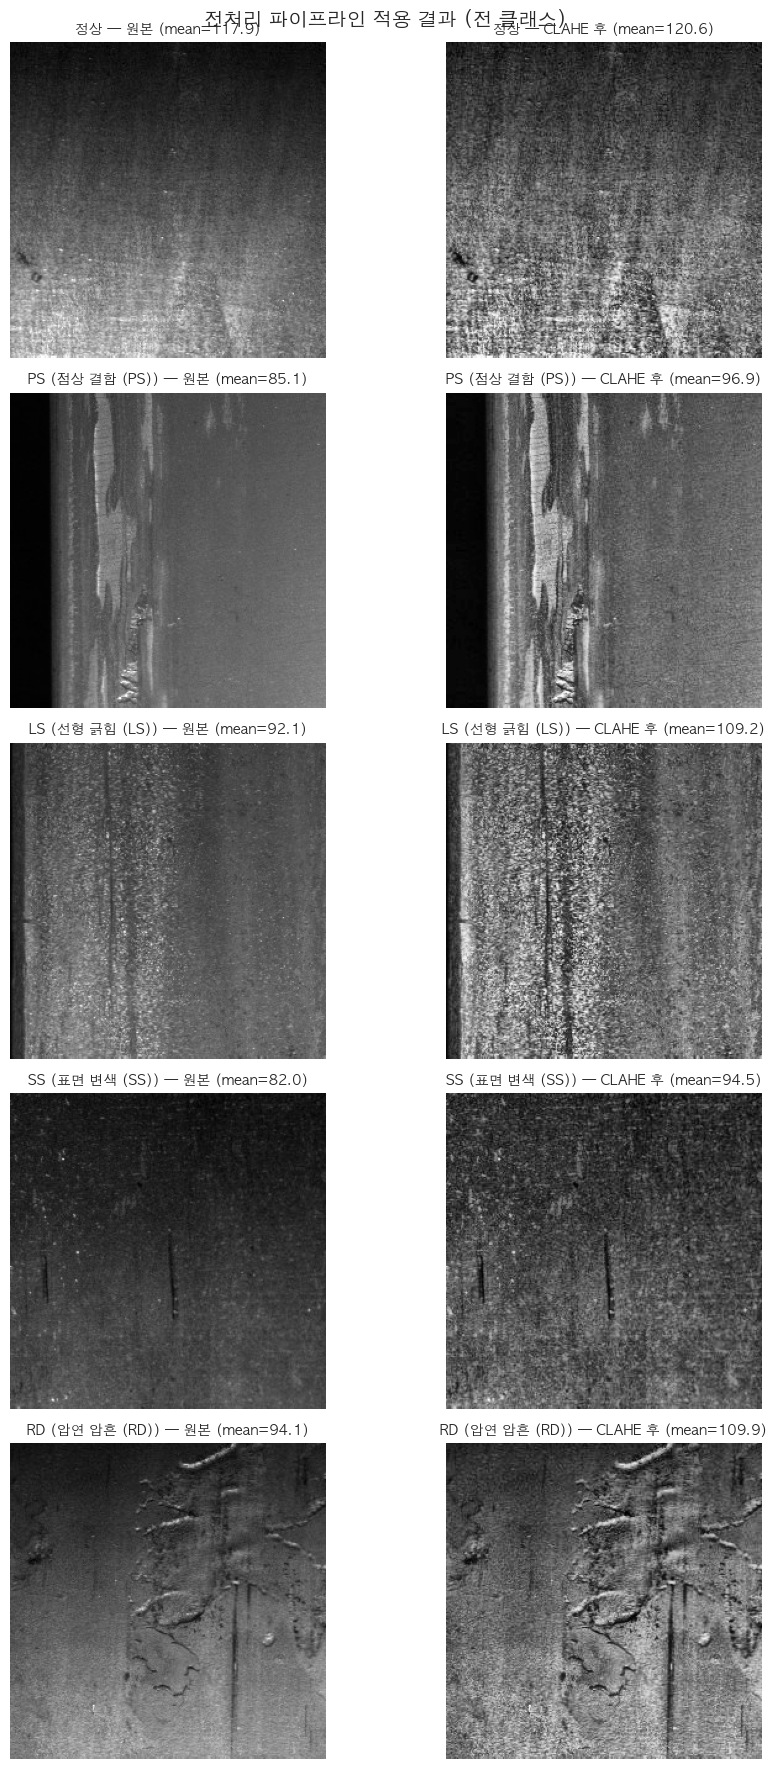

In [9]:
from preprocessing.normalization import clahe_equalization
from preprocessing.filters import bilateral_filter
from preprocessing.sharpening import adaptive_sharpen

def preprocessing_pipeline(img, clip_limit=2.0):
    """통합 전처리 파이프라인"""
    result = clahe_equalization(img, clip_limit=clip_limit)
    return result

fig, axes = plt.subplots(5, 2, figsize=(10, 18))
all_samples = [('정상', normal_imgs[0])]
for cid in [1, 2, 3, 4]:
    mask = labels_d4 == cid
    if mask.sum() > 0:
        all_samples.append((f'{CLASS_ABBR[cid]} ({CLASS_NAMES_KR[cid]})', images_d4[mask][0]))

for i, (label, img) in enumerate(all_samples):
    processed = preprocessing_pipeline(img)
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f'{label} — 원본 (mean={img.mean():.1f})', fontsize=10)
    axes[i, 0].axis('off')
    axes[i, 1].imshow(processed, cmap='gray')
    axes[i, 1].set_title(f'{label} — CLAHE 후 (mean={processed.mean():.1f})', fontsize=10)
    axes[i, 1].axis('off')

fig.suptitle('전처리 파이프라인 적용 결과 (전 클래스)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_pipeline_result.png'), dpi=150, bbox_inches='tight')
plt.show()

### 전처리 전후 밝기 통계 비교

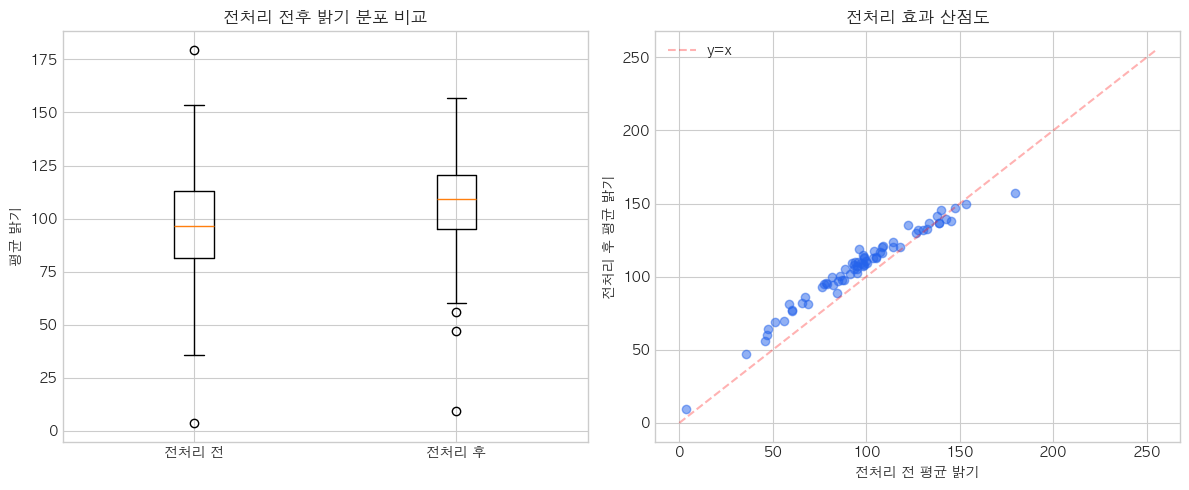

전처리 전 평균 밝기: 96.9 ± 30.5
전처리 후 평균 밝기: 106.8 ± 25.8
→ 밝기 편차 감소: 30.5 → 25.8


In [10]:
all_imgs = list(normal_imgs[:30])
for cid in [1,2,3,4]:
    mask = labels_d4 == cid
    if mask.sum() > 0:
        all_imgs.extend(list(images_d4[mask][:10]))
all_imgs = np.array(all_imgs)

before_means = [img.mean() for img in all_imgs]
after_means = [preprocessing_pipeline(img).mean() for img in all_imgs]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([before_means, after_means], labels=['전처리 전', '전처리 후'])
axes[0].set_ylabel('평균 밝기')
axes[0].set_title('전처리 전후 밝기 분포 비교', fontsize=12, fontweight='bold')

axes[1].scatter(before_means, after_means, alpha=0.5, c='#2563eb')
axes[1].plot([0, 255], [0, 255], 'r--', alpha=0.3, label='y=x')
axes[1].set_xlabel('전처리 전 평균 밝기')
axes[1].set_ylabel('전처리 후 평균 밝기')
axes[1].set_title('전처리 효과 산점도', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_before_after_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"전처리 전 평균 밝기: {np.mean(before_means):.1f} ± {np.std(before_means):.1f}")
print(f"전처리 후 평균 밝기: {np.mean(after_means):.1f} ± {np.std(after_means):.1f}")
print(f"→ 밝기 편차 감소: {np.std(before_means):.1f} → {np.std(after_means):.1f}")

## 결론

### 핵심 발견
1. **Severstal 패치 특성**: 256×256 크기, 정상과 결함 간 밝기 차이 존재
2. **정렬**: 슬라이딩 윈도우 크롭으로 기하학적 정렬 불필요, 하지만 auto_deskew 기능 확보
3. **ROI**: 에지 밀도 맵으로 결함 집중 영역 식별 가능
4. **정규화**: CLAHE(clip=2.0)가 결함 보존 + 대비 개선에 최적
5. **파이프라인**: CLAHE 정규화로 클래스 간 밝기 편차 감소

→ 다음 노트북(02)에서 필터링 및 샤프닝으로 결함 가시성을 더 향상시킵니다.